In [36]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

In [37]:
X, y = make_regression(
    n_samples = 100,
    n_features=100,
    n_informative=10,
    noise = 30,
    random_state=42
)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state=42
)

In [39]:
lr = LinearRegression()

In [40]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:
y_pred_lr = lr.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred_lr))

R2 Score: 0.6858318283336498


In [42]:
print("Training R2:", lr.score(X_train, y_train))
print("Testing R2:", lr.score(X_test, y_test))

Training R2: 1.0
Testing R2: 0.6858318283336498


In [43]:
# Ridge Regression

ridge = Ridge(alpha = 1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_ridge))

R2 Score: 0.6942567712300194


In [44]:
for i in [2, 3, 4, 5, 6, 7, 8, 9, 10]:

    ridge = Ridge(alpha = i)
    ridge.fit(X_train, y_train)

    y_pred_ridge = ridge.predict(X_test)

    print(f"alpha {i}-> R2 Score:", r2_score(y_test, y_pred_ridge))


alpha 2-> R2 Score: 0.6953845194396633
alpha 3-> R2 Score: 0.6933398626894949
alpha 4-> R2 Score: 0.6897623049405874
alpha 5-> R2 Score: 0.6854127819568118
alpha 6-> R2 Score: 0.6806793366042665
alpha 7-> R2 Score: 0.6757720335559682
alpha 8-> R2 Score: 0.670808856100396
alpha 9-> R2 Score: 0.6658573236870996
alpha 10-> R2 Score: 0.6609561209557259


In [45]:
# Lesso Regression

lasso = Lasso(alpha=1.0)

lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("Lasso Regression R2 Score:")
print(r2_score(y_test, y_pred_lasso))

Lasso Regression R2 Score:
0.9295075128902986


In [46]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'Train R2': [
        lr.score(X_train, y_train),
        ridge.score(X_train, y_train),
        lasso.score(X_train, y_train)
    ],
    'Test R2': [
        lr.score(X_test, y_test),
        ridge.score(X_test, y_test),
        lasso.score(X_test, y_test)
    ]
})

results

,Model,Train R2,Test R2
0,Linear Regression,1.000000,0.685832
1,Ridge,0.984789,0.660956
2,Lasso,0.990830,0.929508


In [47]:
coef_df = pd.DataFrame({
    'Linear': lr.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
})

coef_df.head()

,Linear,Ridge,Lasso
0,-11.187217,-6.111605,-3.958477
1,-7.766501,-6.896632,-0.000000
2,-3.625787,-0.134437,-0.000000
3,6.257283,9.912196,0.000000
4,45.057203,35.848602,36.037976


In [48]:
print("Features removed by Lasso:")
print(np.sum(lasso.coef_ == 0))

Features removed by Lasso:
43


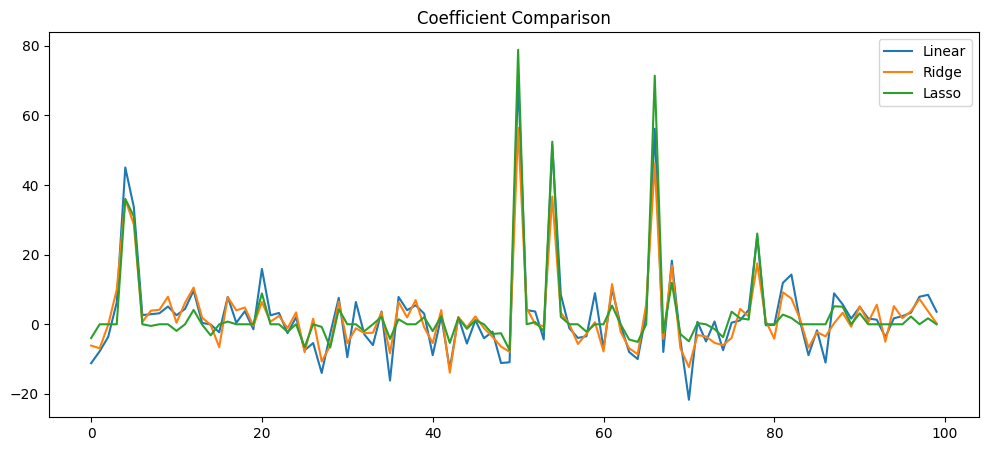

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(lr.coef_, label='Linear')
plt.plot(ridge.coef_, label='Ridge')
plt.plot(lasso.coef_, label='Lasso')

plt.legend()
plt.title("Coefficient Comparison")
plt.show()